<a href="https://colab.research.google.com/github/CSrory/genai-bootcamp-lab1/blob/main/Copy_of_W4_Capstone_Starter_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Capstone Starter — Build Your GenAI App</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 4 — Pick a track (A / B / C), fill the TODOs, deploy</div>
    </div>
    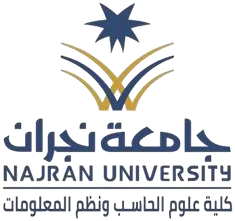
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENL + NCA-GENM track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: the whole week</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Reuse helper functions from earlier labs: <b>load an LLM</b>, <b>embed + retrieve</b>, a <b>Gradio shell</b>.</li>
<li style="margin:5px 0;">Pick <b>one track</b> (A: LLM/RAG · B: Multimodal · C: Prompt tool) and run only its cells.</li>
<li style="margin:5px 0;">Replace every <b>TODO</b> with your own data / inputs to make the project yours.</li>
<li style="margin:5px 0;">Launch a working demo and follow the <b>Hugging Face Space</b> deploy checklist.</li></ul></div>

# How to use this starter

This is a **scaffold you copy and make your own**. It has three tracks — you only need **one**.

1. Run the **shared setup** (Part 0) at the start of every session — Colab runtimes reset, so you'll re-run it each time you come back to this notebook.
2. Jump to **your track** (Part A, B, **or** C) and run those cells.
3. Replace every cell marked `# TODO` with your own data / inputs.
4. Run the **Gradio shell** to get a live demo.
5. Follow the **deploy checklist** to publish a Hugging Face Space.

Every model here is **open and ungated** — no login or token needed.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 First: turn on the free GPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click <b>Runtime → Change runtime type → T4 GPU → Save</b>. Everything also runs on CPU, just slower. Then run Part 0 below.</div></div>

## Part 0 — Shared setup (run this once)

Installs the libraries used by all three tracks and defines helpers you will reuse. This is the same toolkit you practised in Weeks 1–3.

In [1]:
# One-time setup (~1-2 minutes). Safe to re-run.
!pip -q install -U "transformers>=4.56,<6" accelerate sentence-transformers gradio "pillow==11.3.0"

# Keep the output clean (hides harmless library deprecation notices)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

print("Setup complete - now run the cells below in order.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 31.5 MB/s eta 0:00:00
Setup complete - now run the cells below in order.


In [2]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)
if DEVICE == "cpu":
    print("Tip: enable the T4 GPU (see the setup box) for much faster generation.")

Running on: cuda


### Helper 1 — Load a small open LLM and chat with it *(from the Week-2 LLM lab)*

`Qwen2.5-1.5B-Instruct` is ungated and fits the free T4 in fp16 (~3 GB). All three tracks can use this `chat()` helper.

In [ ]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [9]:
from transformers import AutoModelForCausalLM, AutoTokenizer

LLM_ID = "Qwen/Qwen2.5-1.5B-Instruct"   # open & ungated - no token needed
tokenizer = AutoTokenizer.from_pretrained(LLM_ID)

llm = AutoModelForCausalLM.from_pretrained(
    LLM_ID,
    dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto",
)
print("LLM loaded:", LLM_ID)


def chat(prompt, system=None, max_new_tokens=200, **gen_kwargs):
    """Send a prompt to the instruct model and return its reply as text."""
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=False,   # return_dict=False -> plain tensor
    ).to(llm.device)
    out = llm.generate(inputs, max_new_tokens=max_new_tokens,
                       pad_token_id=tokenizer.eos_token_id, **gen_kwargs)
    return tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True).strip()


print(chat("Say hello to the Najran bootcamp in one short sentence."))

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM loaded: Qwen/Qwen2.5-1.5B-Instruct
The Najran Bootcamp is an intensive program designed to provide aspiring developers with hands-on experience and industry-relevant skills through practical training and mentorship.


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Decoding knobs you already know</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Pass <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">do_sample=False</code> for factual answers, or <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">do_sample=True, temperature=0.8, top_p=0.9</code> for creative ones — straight from the Week-2 lab.</div></div>

## Part A — LLM / RAG application

**Choose this track** to build a chat/Q&A app that answers from **your own documents** instead of the model's memory. Skip to Part B or C if you picked another track.

*Builds on:* the LLM lab + the embeddings/RAG lab.

### Helper 2 — Embed + retrieve *(from the RAG lab)*
We embed every document chunk once, then find the closest chunks to a question with cosine similarity. No vector database needed for a small demo.

In [10]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)

# TODO: replace these with YOUR knowledge snippets (handbook, notes, FAQs...).
#       Keep each chunk short (1-4 sentences). Add as many as you like.
documents = [

    """
    Al-Ukhdood Archaeological Site is located in Najran.
    It contains ancient stone ruins, inscriptions, foundations, and archaeological remains connected to the history of southern Arabia.
    """,

    """
    Hegra is located in AlUla.
    It is famous for monumental Nabataean tombs carved into sandstone rock formations in a desert landscape.
    """,

    """
    At-Turaif District is located in Diriyah near Riyadh.
    It was an important center of the First Saudi State and is known for traditional Najdi mud-brick architecture.
    """,

    """
    Historic Jeddah, also known as Al-Balad, is an old urban district in Jeddah.
    It is known for coral-stone buildings and traditional wooden Rawasheen balconies.
    """,

    """
    Al-Ahsa Oasis is located in the Eastern Province.
    It is known for extensive palm groves, natural springs, historic buildings, and a long tradition of human settlement.
    """,

    """
    Hima Cultural Area is located in Najran.
    It is known for rock art, ancient inscriptions, and archaeological evidence linked to historic travel routes.
    """,

    """
    The Rock Art of the Hail Region includes Jubbah and Shuwaymis.
    The sites are known for extensive ancient petroglyphs carved into rocky landscapes.
    """,

    """
    Al-Faw Archaeological Area is an ancient settlement in Saudi Arabia.
    It contains archaeological remains, ancient roads, tombs, and evidence of historic trade and settlement.
    """,

    """
    Rijal Almaa Heritage Village is located in the Asir Region.
    It is known for tall multi-story stone buildings and distinctive traditional architecture surrounded by mountains.
    """,

    """
    Dhee Ayn Heritage Village is located in Al-Baha.
    It is a historic stone village built on a white rocky hill and surrounded by a mountainous landscape.
    """,

    """
    Tabuk Castle is a historic castle in Tabuk.
    It is known for its stone walls, defensive architecture, courtyard, and connection to historic travel routes.
    """,

    """
    Al Masmak Palace is located in Riyadh.
    It is a historic mud-brick fortress known for thick walls, watchtowers, and a large traditional wooden gate.
    """,

    """
    Shubra Palace is located in Taif.
    It is a historic palace known for ornate architecture, multiple floors, balconies, and decorative details.
    """,

    """
    Ushaiqer Heritage Village is a traditional Najdi village.
    It is known for mud-brick houses, narrow pathways, traditional doors, and historic mosques.
    """,

    """
    Al Musawkaf Traditional Market is located in Unaizah.
    It reflects traditional Najdi market architecture and contains heritage-style shops and covered walkways.
    """,

    """
    Fayd Archaeological Site is located in the Hail Region.
    It was an important station on the historic Darb Zubaydah pilgrimage route and contains archaeological ruins.
    """,

    """
    The Hejaz Railway includes historic railway stations and infrastructure in western and northern Saudi Arabia.
    It is recognized by old stone station buildings, railway tracks, and historic transport structures.
    """,

    """
    Darb Zubaydah is a historic pilgrimage route connecting Iraq with Makkah.
    Archaeological remains along the route include wells, reservoirs, stations, and road structures.
    """,

    """
    The Ancient Walled Oases of Northern Arabia include historic oasis settlements.
    They are characterized by fortified walls, traditional settlements, palm groves, and desert landscapes.
    """,

    """
    Jerash Archaeological Site is located in the Asir Region.
    It contains ancient stone structures, archaeological remains, and evidence of historic settlement and activity.
    """
]

doc_embeddings = embedder.encode(documents, normalize_embeddings=True)
print(f"Indexed {len(documents)} heritage chunks.")


def retrieve(query, k=3):
    """Return the k most relevant document chunks for a query."""
    q = embedder.encode([query], normalize_embeddings=True)[0]
    scores = doc_embeddings @ q                    # cosine similarity
    top = np.argsort(-scores)[:k]
    return [documents[i] for i in top]

def retrieve_with_scores(query, k=3):
    q = embedder.encode([query], normalize_embeddings=True)[0]
    scores = doc_embeddings @ q
    top = np.argsort(-scores)[:k]

    return [(documents[i], float(scores[i])) for i in top]


print(retrieve("ancient rock-cut tombs in Saudi Arabia?"))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Indexed 20 heritage chunks.
['\n    Al-Faw Archaeological Area is an ancient settlement in Saudi Arabia.\n    It contains archaeological remains, ancient roads, tombs, and evidence of historic trade and settlement.\n    ', '\n    Al-Ukhdood Archaeological Site is located in Najran.\n    It contains ancient stone ruins, inscriptions, foundations, and archaeological remains connected to the history of southern Arabia.\n    ', '\n    The Ancient Walled Oases of Northern Arabia include historic oasis settlements.\n    They are characterized by fortified walls, traditional settlements, palm groves, and desert landscapes.\n    ']


In [11]:
def rag_answer(question, k=3):
    """Retrieve context, then ask the LLM to answer using ONLY that context."""
    context = "\n".join(f"- {c}" for c in retrieve(question, k))
    system = ("You are Saudi Lens, a careful Saudi cultural heritage assistant. "
        "Answer using ONLY the provided context. "
        "Do not invent historical facts. "
        "If the answer is not in the context, say you do not know.")
    prompt = f"Context:\n{context}\n\nQuestion: {question}"
    return rag_answer_prompt(prompt, system)


def rag_answer_prompt(prompt, system):
    return chat(prompt, system=system, max_new_tokens=180, do_sample=False)


print(rag_answer("What is Hegra known for ?"))

Hegra is known for its monumental Nabataean tombs carved into sandstone rock formations in a desert landscape.


<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENL</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">RAG sits across <b>Core ML & AI</b> and <b>Software Development</b>. Be ready to explain why grounding an LLM in retrieved context reduces hallucination — your demo *shows* it.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Make Track A yours</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Replace <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">documents</code> above with <b>your own</b> snippets, then ask a question your knowledge base can answer. Confirm the model says *I don't know* for an off-topic question.</div></div>

In [12]:
# TODO: after editing `documents` and re-running the embed cell, test here.
print(rag_answer("Where is At-Turaif ?"))
print(rag_answer("Who won the World Cup in 1990?"))  # should say it does not know

At-Turaif is located in Diriyah, which is near Riyadh.
I do not have information about who won the World Cup in 1990. My knowledge base does not include such specific sports or historical events beyond what has been provided in my training data.


## Part B — Multimodal application

**Choose this track** to build an app that understands **images** (caption / visual Q&A). Skip to Part C if you picked another track.

*Builds on:* the Week-3 vision labs. Models are open & ungated (BLIP base, ~1 GB).

In [13]:
import sys
!{sys.executable} -m pip install "Pillow==11.3.0"

In [14]:
from transformers import BlipProcessor, BlipForConditionalGeneration, BlipForQuestionAnswering
from PIL import Image
import requests
from io import BytesIO

caption_proc = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
caption_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base").to(DEVICE)

vqa_proc = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base").to(DEVICE)
print("Vision models loaded (BLIP caption + VQA).")


def load_image(path_or_url):
    """Load a PIL image from a local path or an http(s) URL."""
    if str(path_or_url).startswith("http"):
        resp = requests.get(path_or_url, timeout=20)
        return Image.open(BytesIO(resp.content)).convert("RGB")
    return Image.open(path_or_url).convert("RGB")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Vision models loaded (BLIP caption + VQA).


In [15]:
from transformers import CLIPProcessor, CLIPModel #اضفت كليب لاني ابغاه يحاول يميز الصور بصورة حقيقية
import torch
clip_id = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(clip_id)
clip_model = CLIPModel.from_pretrained(clip_id).to(DEVICE)
print("CLIP loaded.")


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded.


In [16]:
site_candidates = {

    "Al-Ukhdood": "ancient stone archaeological ruins, rectangular stone foundations, carved stones and inscriptions in a dry Najran landscape",

    "Hegra": "monumental Nabataean tomb facades carved directly into massive sandstone rock formations in a desert",

    "At-Turaif": "large historic Najdi mud-brick palaces, defensive walls and traditional ruins in Diriyah",

    "Historic Jeddah": "dense old city with tall coral stone houses, colorful wooden rawasheen balconies and narrow historic streets",

    "Al-Ahsa Oasis": "large green oasis filled with dense palm groves, natural springs and historic buildings",

    "Hima Cultural Area": "desert rock surfaces covered with ancient petroglyphs, animal carvings and inscriptions",

    "Hail Rock Art": "large rocky cliffs and boulders covered with ancient human and animal petroglyph carvings",

    "Al-Faw": "large ancient desert settlement with stone ruins, archaeological foundations, tombs and historic structures",

    "Rijal Almaa": "tall multi-story traditional stone towers and colorful heritage buildings surrounded by green mountains",

    "Dhee Ayn": "historic gray stone village built dramatically on top of a bright white rocky hill in mountainous terrain",

    "Tabuk Castle": "historic rectangular stone castle with defensive walls, towers, courtyard and traditional stone architecture",

    "Al Masmak Palace": "large brown mud-brick fortress with thick walls, round watchtowers and a traditional wooden gate",

    "Shubra Palace": "ornate historic multi-story palace with white walls, decorative balconies, windows and architectural details",

    "Ushaiqer": "traditional Najdi mud-brick village with narrow alleys, old wooden doors and earth-colored historic houses",

    "Al Musawkaf Market": "traditional covered Najdi market with heritage shops, wooden doors and mud-brick style architecture",

    "Fayd Archaeological Site": "ancient stone ruins, wells and archaeological structures along a desert pilgrimage route",

    "Hejaz Railway": "historic stone railway station, old railway tracks and early transport infrastructure in a desert landscape",

    "Darb Zubaydah": "historic desert pilgrimage route with ancient stone wells, water reservoirs and station ruins",

    "Northern Walled Oases": "fortified desert oasis settlement with old defensive walls, traditional buildings and palm groves",

    "Jerash Archaeological Site": "ancient stone archaeological foundations, walls and settlement ruins in southern Saudi Arabia"
}


def identify_site_with_clip(image):
    site_names = list(site_candidates.keys())
    descriptions = list(site_candidates.values())

    inputs = clip_processor(
        text=descriptions,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(DEVICE)

    with torch.no_grad():
        outputs = clip_model(**inputs)

    scores = outputs.logits_per_image.softmax(dim=1)[0]

    best_index = scores.argmax().item()

    return site_names[best_index], scores[best_index].item()

In [17]:
img = load_image("/content/images.jpg")

In [18]:
site, score = identify_site_with_clip(img)
print("Possible Site :", site)
print("CLIP Score :", score)

Possible Site : Al-Ukhdood
CLIP Score : 0.3584536015987396


In [20]:
def caption_image(image):
    """Return a one-line description of an image."""
    inputs = caption_proc(
        image,
        return_tensors="pt"
    ).to(DEVICE)

    out = caption_model.generate(
        **inputs,
        max_new_tokens=30
    )

    return caption_proc.decode(
        out[0],
        skip_special_tokens=True
    )


def ask_image(image, question):
    """Answer a natural-language question about an image (visual Q&A)."""
    inputs = vqa_proc(
        image,
        question,
        return_tensors="pt"
    ).to(DEVICE)

    out = vqa_model.generate(
        **inputs,
        max_new_tokens=20
    )

    return vqa_proc.decode(
        out[0],
        skip_special_tokens=True
    )


def saudi_lens(image):
    caption = caption_image(image)

    site_name, clip_score = identify_site_with_clip(image)

    results = retrieve_with_scores(site_name, k=3)

    context = "\n".join(
        document for document, score in results
    )

    prompt = f"""
You are Saudi Lens, an AI cultural heritage guide.

Image description:
{caption}

CLIP visual match:
{site_name}

Retrieved Saudi heritage information:
{context}

Based on the CLIP visual match and ONLY the retrieved heritage information,
provide information about the most likely Saudi heritage site.

Provide:
- Possible Site
- Region
- Cultural Overview
- Historical Context
- Why It Matters

Do not invent historical facts.
"""

    answer = chat(
        prompt,
        system="""
You are a careful Saudi cultural heritage assistant.
Use only the provided context.
Do not invent historical facts.
""",
        max_new_tokens=220,
        do_sample=False
    )

    return caption, answer
sample_url = "/content/Hegra.jpg"

img = load_image(sample_url)

print("Caption:", caption_image(img))
print("Q&A:", ask_image(img, "What type of historical place is shown in the picture?"))

caption, answer = saudi_lens(img)

print("\nSAUDI LENS CAPTION:", caption)
print("\nSAUDI LENS ANSWER:\n", answer)

Caption: the ruins of the ancient city of person
Q&A: ancient

SAUDI LENS CAPTION: the ruins of the ancient city of person

SAUDI LENS ANSWER:
 The most likely Saudi heritage site based on the CLIP visual match and the provided heritage information is **Hegra**. 

### Region: AlUla
AlUla is a region in northwestern Saudi Arabia that has been identified as a UNESCO World Heritage Site due to its rich cultural and natural heritage. This area is renowned for its monumental Nabataean tombs carved into sandstone rock formations, which align with the characteristics described in the context.

### Cultural Overview: Ancient Nabatean Tombs
Hegra is situated within this region and features some of the best-preserved Nabataean tombs found outside of Petra. These tombs were carved into the soft sandstone cliffs, showcasing intricate carvings and architectural styles typical of the Nabataean civilization. The tombs provide valuable insights into the burial practices, religious beliefs, and social 

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Upload your own image in Colab</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Use the <b>Files</b> tab (📁, left sidebar) to upload a photo, then call <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">load_image('/content/your_photo.jpg')</code>. Or drag a file in and copy its path.</div></div>

<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENM</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Captioning and VQA are core <b>Multimodal Data</b> topics. Know that a vision-language model aligns image features with text — your demo is a working example of that alignment.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Make Track B yours</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Load an image that matters to your project (heritage site, plant, document...) and ask it two useful questions. Combine BLIP with the <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">chat()</code> helper for richer answers.</div></div>

In [ ]:
# TODO: point this at your own image and questions
my_img = load_image(sample_url)   # <- replace with your image path/URL
caption = caption_image(my_img)
print("Caption:", caption)
# Use the LLM to turn a short caption into a friendly description:
print(chat(f"Write one friendly sentence about this photo: {caption}"))

## Part C — Prompt-engineering tool

**Choose this track** to build a tool that helps people **write and test better prompts** — templates, parameter sweeps, and side-by-side comparisons.

*Builds on:* the Week-2 prompt-engineering lab. Uses the shared `chat()` helper (run Part 0).

In [ ]:
PROMPT_TEMPLATES = {
    # TODO: add your own reusable templates. Use {placeholders} for the user input.
    "summarize":  "Summarize the following text in 3 bullet points:\n\n{input}",
    "email":      "Write a polite, professional email about: {input}",
    "explain":    "Explain this to a beginner in 2 short sentences: {input}",
}


def run_template(name, user_input, **gen_kwargs):
    """Fill a named template with the user input and send it to the model."""
    prompt = PROMPT_TEMPLATES[name].format(input=user_input)
    return chat(prompt, **gen_kwargs)


print(run_template("explain", "What is a context window in an LLM?", do_sample=False))

In [ ]:
def compare_temperatures(prompt, settings=((0.0, False), (0.3, True), (1.1, True))):
    """Run the same prompt at several temperatures so users can compare outputs."""
    from transformers import set_seed
    results = {}
    for temp, sample in settings:
        set_seed(0)
        kwargs = {"do_sample": True, "temperature": temp, "top_p": 0.9} if sample else {"do_sample": False}
        results[f"temp={temp}"] = chat(prompt, max_new_tokens=40, **kwargs)
    return results


for label, text in compare_temperatures("Give a slogan for an AI bootcamp in Najran.").items():
    print(f"[{label}] {text}\n")

<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENL / NCA-GENM</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Comparing decoding settings is the heart of the <b>Experimentation</b> domain (the most-weighted on NCA-GENM). A tool that makes this comparison visual is a strong capstone.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Make Track C yours</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Add one new template to <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">PROMPT_TEMPLATES</code>, then build a tiny <b>prompt scorer</b>: ask the model to rate its own answer 1–5 for clarity. (Fill in the TODO.)</div></div>

In [ ]:
# TODO: add a template above, then score an output here.
answer = run_template("summarize", "Your text to summarize goes here.", do_sample=False)
print("Answer:", answer)
score = chat(f"Rate this summary 1-5 for clarity and reply with just the number:\n{answer}",
             do_sample=False, max_new_tokens=5)
print("Self-score:", score)

## Part 4 — Wrap your project in a Gradio app *(all tracks)*

A Gradio app gives your demo a web UI and is exactly what a Hugging Face Space runs. Edit the `respond()` function to call **your track's** function.

<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ Point respond() at your track</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">The shell below defaults to the <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">chat()</code> helper. Replace the marked line with <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">rag_answer(message)</code> (Track A), an image handler (Track B), or <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">run_template(...)</code> (Track C).</div></div>

In [39]:
import gradio as gr
import torch
import numpy as np

from PIL import Image
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BlipProcessor,
    BlipForConditionalGeneration,
    BlipForQuestionAnswering,
    CLIPProcessor,
    CLIPModel
)



def build_preferences(depth, style, language, region):

    depth_map = {
        "Quick Glimpse": "Keep the answer short and concise.",
        "Cultural Overview": "Give a clear medium-length overview.",
        "Deep Heritage Dive": "Give a detailed cultural and historical explanation."
    }

    style_map = {
        "Educational": "Use an educational and informative style.",
        "Tour Guide": "Speak like a friendly Saudi heritage tour guide.",
        "Historical Storytelling": "Use an engaging historical storytelling style.",
        "Simple Explorer": "Explain everything in a simple beginner-friendly way."
    }

    return depth_map[depth], style_map[style]

def translate_query_for_search(message):

    prompt = f"""
Translate the following Saudi heritage question into clear English
for semantic search.

Return only the English search query.

Question:
{message}
"""

    return chat(
        prompt,
        system="""
You translate Arabic Saudi heritage questions
into concise English search queries.
Return only the translated search query.
""",
        max_new_tokens=60,
        do_sample=False
    )

def heritage_chat(message, depth, style, language, region):

    if not message or not message.strip():

        if language == "العربية":
            return "اكتب سؤالك عن التراث السعودي."

        return "Please ask a question about Saudi heritage."

    depth_instruction, style_instruction = build_preferences(
        depth,
        style,
        language,
        region
    )

    if language == "العربية":
        search_query = translate_query_for_search(message)
    else:
        search_query = message

    if region != "All Saudi Arabia":
        search_query += f" Saudi heritage in {region}"

    context = "\n".join(
        f"- {c}" for c in retrieve(search_query, k=3)
    )

    if language == "العربية":

        prompt = f"""
المعلومات المسترجعة من قاعدة المعرفة:

{context}

سؤال المستخدم:

{message}

أجب باللغة العربية الفصحى الطبيعية والواضحة.

تعليمات الإجابة:

- {depth_instruction}
- {style_instruction}

اعتمد فقط على المعلومات المسترجعة.
لا تخترع أي معلومات تاريخية.

إذا لم تكن الإجابة موجودة في المعلومات، قل بوضوح:

لا تتوفر معلومات كافية في قاعدة معرفة Saudi Lens.
"""

        system = """
أنت Saudi Lens، مساعد متخصص في التراث الثقافي السعودي.

اكتب باللغة العربية الفصحى الطبيعية والواضحة.
لا تستخدم ترجمة حرفية ركيكة.
استخدم فقط السياق المقدم.
لا تخترع أي حقائق تاريخية.
"""
    else:

        prompt = f"""
Retrieved Saudi heritage information:

{context}

User question:

{message}

Instructions:

- {depth_instruction}
- {style_instruction}

Use only the retrieved information.
Do not invent historical facts.

If the answer is not available in the retrieved information,
clearly say that Saudi Lens does not have enough information.
"""

        system = """
You are Saudi Lens,
a careful Saudi cultural heritage assistant.

Use only the provided context.
Do not invent historical facts.
"""

    return chat(
        prompt,
        system=system,
        max_new_tokens=350,
        do_sample=False
    )

def heritage_image(image, depth, style, language, region):

    if image is None:

        if language == "العربية":
            return "الرجاء رفع صورة لموقع تراثي."

        return "Please upload a Saudi heritage image."

    caption, grounded_answer = saudi_lens(image)

    depth_instruction, style_instruction = build_preferences(
        depth,
        style,
        language,
        region
    )

    if language == "العربية":

        prompt = f"""
الوصف البصري للصورة:

{caption}

التحليل الموثق:

{grounded_answer}

أعد صياغة التحليل باللغة العربية الفصحى الطبيعية والواضحة.

تعليمات:

- {depth_instruction}
- {style_instruction}
- لا تغير اسم الموقع المحدد
- لا تضف معلومات تاريخية غير موجودة
- تجنب الترجمة الحرفية والعبارات الركيكة
"""

        system = """
أنت Saudi Lens، مرشد متخصص في التراث السعودي.

أعد صياغة المعلومات باللغة العربية الفصحى
الطبيعية والواضحة.

لا تخترع أي معلومات جديدة.
"""

    else:

        prompt = f"""
Visual description:

{caption}

Grounded heritage analysis:

{grounded_answer}

Rewrite the result clearly.

Instructions:

- {depth_instruction}
- {style_instruction}
- Do not change the identified heritage site
- Do not invent historical facts
"""

        system = """
You are Saudi Lens,
a careful Saudi cultural heritage guide.

Use only the provided grounded analysis.
"""

    return chat(
        prompt,
        system=system,
        max_new_tokens=350,
        do_sample=False
    )

custom_css = """

:root,
html,
body {
    color-scheme: light !important;
}

body {
    background: #F4FAF6 !important;
}


.gradio-container {
    max-width: 1400px !important;
    margin: auto !important;

    background: #F4FAF6 !important;
    color: #14532D !important;

    font-family:
        Inter,
        Arial,
        "Segoe UI",
        sans-serif !important;
}


.gradio-container .block,
.gradio-container .panel,
.gradio-container .form,
.gradio-container .wrap,
.gradio-container .container,
.gradio-container .compact,
.gradio-container .gap {
    background: #FFFFFF !important;
    color: #14532D !important;
}


.hero {
    text-align: center;

    padding: 32px 20px;

    background: linear-gradient(
        135deg,
        #F7FCF8,
        #EAF7EE
    ) !important;

    border: 1px solid #C7E4CF;

    border-radius: 18px;

    margin-bottom: 20px;
}

.hero h1 {
    color: #14532D !important;

    font-size: 48px !important;

    font-weight: 800 !important;

    margin: 0 !important;
}

.hero p {
    color: #245B38 !important;

    font-size: 18px !important;

    margin-top: 8px !important;
}


.gradio-container label,
.gradio-container span,
.gradio-container p,
.gradio-container strong,
.gradio-container h1,
.gradio-container h2,
.gradio-container h3,
.gradio-container h4,
.gradio-container h5,
.gradio-container h6 {
    color: #166534 !important;
}

.gradio-container .block-info,
.gradio-container .block-title,
.gradio-container .label-wrap,
.gradio-container label > span {
    background: transparent !important;

    color: #166534 !important;

    border: none !important;

    box-shadow: none !important;

    font-weight: 600 !important;
}

.gradio-container input,
.gradio-container textarea {

    background: #FFFFFF !important;

    color: #14532D !important;

    border: 1px solid #86C99B !important;

    border-radius: 10px !important;

    box-shadow: none !important;
}


.gradio-container input::placeholder,
.gradio-container textarea::placeholder {

    color: #71877A !important;

    opacity: 1 !important;
}


.gradio-container input:focus,
.gradio-container textarea:focus {

    border-color: #16A34A !important;

    box-shadow:
        0 0 0 2px rgba(22, 163, 74, 0.12)
        !important;
}


.gradio-container .dropdown,
.gradio-container select,
.gradio-container [role="combobox"] {

    background: #FFFFFF !important;

    color: #14532D !important;

    border-color: #B7DFC3 !important;

    border-radius: 10px !important;
}


.gradio-container [role="combobox"] input,
.gradio-container [role="combobox"] span {

    color: #14532D !important;

    background: #FFFFFF !important;
}

.gradio-container input[type="radio"] {
    accent-color: #16A34A !important;
}

.gradio-container .wrap label {

    background: #FFFFFF !important;

    color: #14532D !important;

    border-color: #D0E8D6 !important;
}


.gradio-container .wrap label:has(input:checked) {

    background: #F0FAF3 !important;

    color: #166534 !important;

    border-color: #16A34A !important;
}


.gradio-container button,
.gradio-container .green-button {

    border-radius: 10px !important;

    font-weight: 700 !important;
}

.gradio-container button.primary,
.gradio-container .green-button {

    background: linear-gradient(
        135deg,
        #16803F,
        #2BC55A
    ) !important;

    color: #FFFFFF !important;

    border: none !important;

    box-shadow: none !important;
}


.gradio-container button.primary:hover,
.gradio-container .green-button:hover {

    background: linear-gradient(
        135deg,
        #166534,
        #1D9E4A
    ) !important;

    color: #FFFFFF !important;
}


.gradio-container .tabs {

    background: #FFFFFF !important;

    border-color: #D3E9D9 !important;
}


.gradio-container .tabs button {

    background: #FFFFFF !important;

    color: #166534 !important;

    border-color: #D3E9D9 !important;
}


.gradio-container .tabs button.selected {

    background: linear-gradient(
        135deg,
        #16803F,
        #32B85A
    ) !important;

    color: #FFFFFF !important;

    border-color: #16803F !important;
}


.question-box {

    background: #FFFFFF !important;

    border: 1px solid #D0E8D6 !important;

    border-radius: 14px !important;

    padding: 10px !important;
}


.output-box {

    background: #FFFFFF !important;

    border: 1px solid #1E9B4B !important;

    border-radius: 12px !important;
}

.output-box textarea {

    background: #FFFFFF !important;

    color: #14532D !important;

    border: none !important;

    min-height: 260px !important;

    font-size: 17px !important;

    line-height: 1.9 !important;

    box-shadow: none !important;
}


.output-box textarea,
.output-box input,
.output-box p,
.output-box span,
.output-box div,
.output-box .prose {

    color: #14532D !important;
}


.image-box {

    background: #FFFFFF !important;

    border: 1px solid #D0E8D6 !important;

    border-radius: 14px !important;
}


.gradio-container [data-testid="image"] {

    background: #FFFFFF !important;

    color: #166534 !important;

    border-color: #16A34A !important;
}


.gradio-container a {

    color: #15803D !important;
}

.gradio-container ::-webkit-scrollbar {
    width: 8px;
}

.gradio-container ::-webkit-scrollbar-thumb {

    background: #86C99B;

    border-radius: 10px;
}



.dark .gradio-container,
.dark .gradio-container .block,
.dark .gradio-container .panel,
.dark .gradio-container .form,
.dark .gradio-container .wrap {

    background: #FFFFFF !important;

    color: #14532D !important;
}

.dark .gradio-container input,
.dark .gradio-container textarea,
.dark .gradio-container select {

    background: #FFFFFF !important;

    color: #14532D !important;
}

"""

with gr.Blocks(

    title="Saudi Lens",

    theme=gr.themes.Soft(
        primary_hue="green",
        secondary_hue="green",
        neutral_hue="gray"
    ),

    css=custom_css

) as demo:

    gr.HTML("""
    <div class="hero">

        <h1> Saudi Lens</h1>

        <p>
            Discover Saudi Arabia's Cultural Heritage Through AI
        </p>

    </div>
    """)

    with gr.Row():

        depth = gr.Radio(

            [
                "Quick Glimpse",
                "Cultural Overview",
                "Deep Heritage Dive"
            ],

            value="Cultural Overview",

            label="Exploration Depth"

        )


        style = gr.Dropdown(

            [
                "Educational",
                "Tour Guide",
                "Historical Storytelling",
                "Simple Explorer"
            ],

            value="Tour Guide",

            label="Exploration Style"

        )


        language = gr.Dropdown(

            [
                "العربية",
                "English"
            ],

            value="العربية",

            label="Language / اللغة"

        )


        region = gr.Dropdown(

            [
                "All Saudi Arabia",
                "Najran",
                "Riyadh",
                "AlUla",
                "Jeddah",
                "Asir"
            ],

            value="All Saudi Arabia",

            label="Region Focus"

        )


    with gr.Tabs():


        with gr.Tab(" Heritage Assistant"):


            question = gr.Textbox(

                label="Ask Saudi Lens / اسأل Saudi Lens",

                placeholder=(
                    "Where is Rijal Almaa Village? "
                    "/ مثال: ما أهمية موقع الأخدود الأثري؟"
                ),

                lines=4,

                elem_classes=["question-box"]

            )


            explore_button = gr.Button(

                " Explore Heritage / استكشف التراث",

                variant="primary",

                elem_classes=["green-button"]
            )
            chat_output = gr.Textbox(

                label="Saudi Lens Answer / إجابة Saudi Lens",

                lines=14,

                interactive=False,

                elem_classes=["output-box"]

            )


            explore_button.click(

                fn=heritage_chat,

                inputs=[
                    question,
                    depth,
                    style,
                    language,
                    region
                ],

                outputs=chat_output

            )


        with gr.Tab(" Heritage Lens"):


            with gr.Row():


                image_input = gr.Image(

                    type="pil",

                    label="Upload Heritage Image / ارفع صورة تراثية",

                    elem_classes=["image-box"]

                )


                image_output = gr.Textbox(

                    label="Saudi Lens Discovery / اكتشاف Saudi Lens",

                    lines=14,

                    interactive=False,

                    elem_classes=["output-box"]

                )


            analyze_button = gr.Button(

                " Discover Heritage Site / اكتشف الموقع التراثي",

                variant="primary",

                elem_classes=["green-button"]

            )


            analyze_button.click(

                fn=heritage_image,

                inputs=[
                    image_input,
                    depth,
                    style,
                    language,
                    region
                ],

                outputs=image_output

            )
if __name__ == "__main__":
    demo.launch()

/tmp/ipykernel_966/840005931.py:609: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://93acdcf2073e29afa5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Track B needs an image input</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">For an image app, swap <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">gr.ChatInterface</code> for <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">gr.Interface(fn=..., inputs=[gr.Image(type='pil'), 'text'], outputs='text')</code> so users can upload a photo and ask a question.</div></div>

## Part 5 — Deploy to a Hugging Face Space

Turn your notebook into a permanent, shareable web app. This is **deliverable #4**.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 Deploy checklist — Hugging Face Space</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;"><b>0.</b> You need a free <b>huggingface.co</b> account (sign up if you haven't already).  <b>1.</b> Go to <b>huggingface.co/new-space</b> → name it → SDK <b>Gradio</b> → <b>Create</b>.  <b>2.</b> Add an <b>app.py</b> with your <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">respond()</code> + <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">demo.launch()</code> (no <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">share=True</code> needed there). Copy your helper functions (<code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">chat()</code>, <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">rag_answer()</code>, ...) <b>verbatim</b> from this notebook — don't retype them from memory, so you keep every fix you already made here.  <b>3.</b> Add a <b>requirements.txt</b> listing your libraries (transformers, torch, gradio, ...) — reuse the cell below.  <b>4.</b> Commit & push (web upload or <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">git</code>); the Space builds and goes live.  <b>5.</b> Paste the Space URL into your write-up and GitHub README.</div></div>

In [27]:
# Generate a starter requirements.txt for your Space (edit to match what YOU used).
requirements = """transformers>=4.56,<6
torch
accelerate
sentence-transformers
gradio
pillow
"""
with open("requirements.txt", "w") as f:
    f.write(requirements)
print(requirements)
print("Saved requirements.txt - download it from the Files tab and add it to your Space.")

transformers>=4.56,<6
torch
accelerate
sentence-transformers
gradio
pillow

Saved requirements.txt - download it from the Files tab and add it to your Space.


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Keep your Space within the free tier</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Free Spaces run on CPU by default. Small models (Qwen 1.5B, MiniLM, BLIP-base) work, but expect slower replies. Load models <b>once</b> at the top of <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">app.py</code>, not inside <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">respond()</code>.</div></div>

<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;">Run <b>Part 0 once</b>, then build in your chosen track — A (RAG), B (multimodal), or C (prompts).</li>
<li style="margin:5px 0;">RAG = <b>embed + retrieve + answer with context</b>; it grounds the LLM and cuts hallucination.</li>
<li style="margin:5px 0;">Multimodal = a <b>vision-language model</b> (BLIP) for captioning and visual Q&A.</li>
<li style="margin:5px 0;">Prompt tools live in the <b>Experimentation</b> domain — compare templates & decoding settings.</li>
<li style="margin:5px 0;">A <b>Gradio</b> app + a <b>Hugging Face Space</b> turn your notebook into a live, shareable demo.</li>
<li style="margin:5px 0;">All four deliverables (demo, write-up, GitHub repo, Space) are required to pass.</li></ul></div>

---
### Submit your work
Push your code to a **public GitHub repo** (reuse your `genai-bootcamp-lab1` account) with a clear README, deploy your **Hugging Face Space**, and attach your **one-page write-up**. Then get ready for **Demo Day on Wednesday**. Build · Ship · Demo!